# House Price Prediction Using Machine Learning

## Project Overview

This project explores how machine learning can be used to predict house prices based on different characteristics of residential areas.

Using the California Housing dataset, I explored the data, prepared the features, trained Linear Regression and Random Forest Regression models, compared their performance, analyzed feature importance, and generated a final prediction.

The project was developed using Python, Pandas, NumPy, Matplotlib, and Scikit-learn.

## Project Contents

1. Problem Statement
2. Dataset
3. Data Exploration
4. Data Preparation
5. Linear Regression
6. Random Forest Regression
7. Model Comparison
8. Feature Importance
9. Error Analysis
10. Final Prediction
11. Conclusion

## 1. Problem Statement

The goal of this project is to build machine learning models that can predict house prices based on characteristics of residential areas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Dataset

This project uses the California Housing dataset available through Scikit-learn.

The dataset contains information about residential areas in California. The features include median income, house age, average number of rooms, average number of bedrooms, population, average household size, latitude, and longitude.

The target variable represents the median house value for each area.

In [ ]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset shape:", df.shape)
print("\nFeature columns:")
print(list(housing.feature_names))
print("\nTarget column:")
print(housing.target_names)

Dataset shape: (20640, 9)

Feature columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target column:
['MedHouseVal']


### First Look at the Dataset

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Checking for Missing Values

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### Basic Statistics

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Exploring House Values

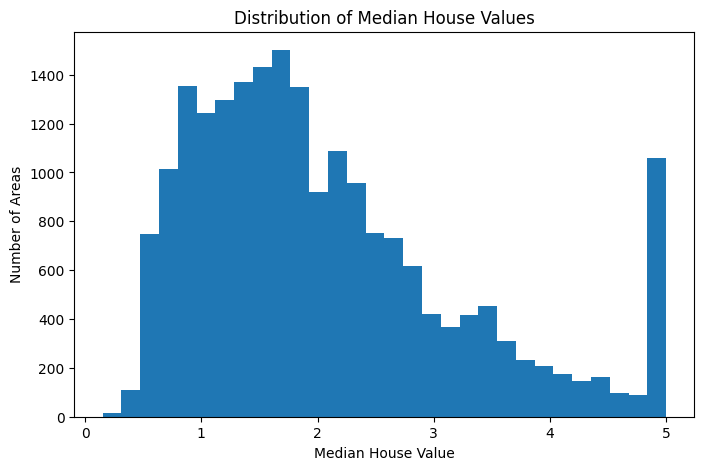

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=30)
plt.xlabel("Median House Value")
plt.ylabel("Number of Areas")
plt.title("Distribution of Median House Values")
plt.show()

### Correlation with House Value

In [ ]:
correlations = df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)

print(correlations)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


## 4. Data Preparation

The target variable is MedHouseVal, which represents the median house value.

The remaining columns are used as input features. The data is divided into training and testing sets so that the models can be evaluated on data they did not see during training.

In [ ]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (16512, 8)
Testing features shape: (4128, 8)
Training target shape: (16512,)
Testing target shape: (4128,)


## 5. Linear Regression Model

Linear Regression is used as a baseline model for predicting median house values.

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Linear Regression Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
--------------------------
MAE : 0.5332001304956553
MSE : 0.5558915986952444
RMSE: 0.7455813830127764
R²  : 0.5757877060324508


### Actual vs Predicted House Values

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

print(comparison.head(10))

    Actual  Predicted
0  0.47700   0.719123
1  0.45800   1.764017
2  5.00001   2.709659
3  2.18600   2.838926
4  2.78000   2.604657
5  1.58700   2.011754
6  1.98200   2.645500
7  1.57500   2.168755
8  3.40000   2.740746
9  4.46600   3.915615


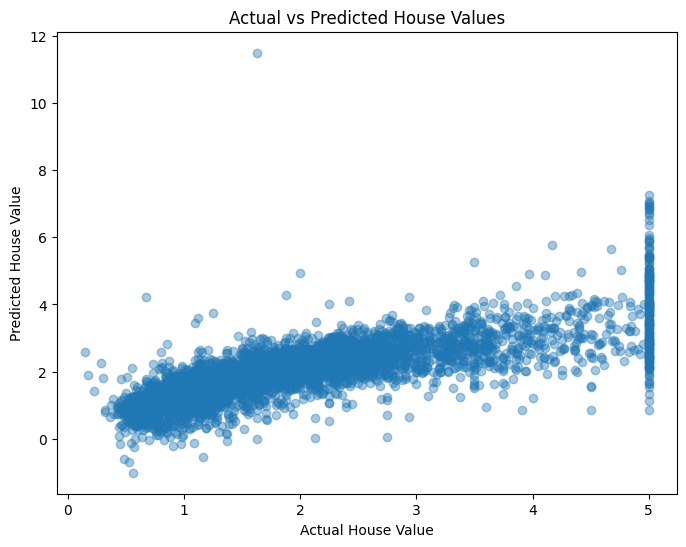

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.4)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

## 6. Random Forest Regression

Random Forest Regression is an ensemble learning method that combines multiple decision trees to make predictions.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 0.32754256845930246
MSE : 0.2553684927247781
RMSE: 0.5053399773665033
R²  : 0.8051230593157366


### Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "MSE": [mse_lr, mse_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Random Forest,0.327543,0.255368,0.505340,0.805123


### Feature Importance

Feature importance shows which input variables contributed most to the Random Forest model's predictions.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,MedInc,0.524871
5,AveOccup,0.138443
6,Latitude,0.088936
7,Longitude,0.088629
1,HouseAge,0.054593
2,AveRooms,0.044272
4,Population,0.030650
3,AveBedrms,0.029606


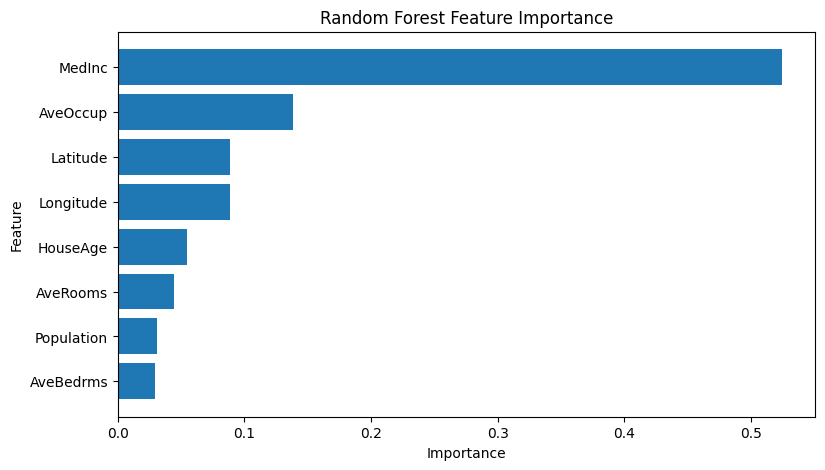

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()